In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ── Load Dataset ─────────────────────────────────────────────
df = pd.read_csv('../data/netflix_catalogue.csv')

print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())

Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64


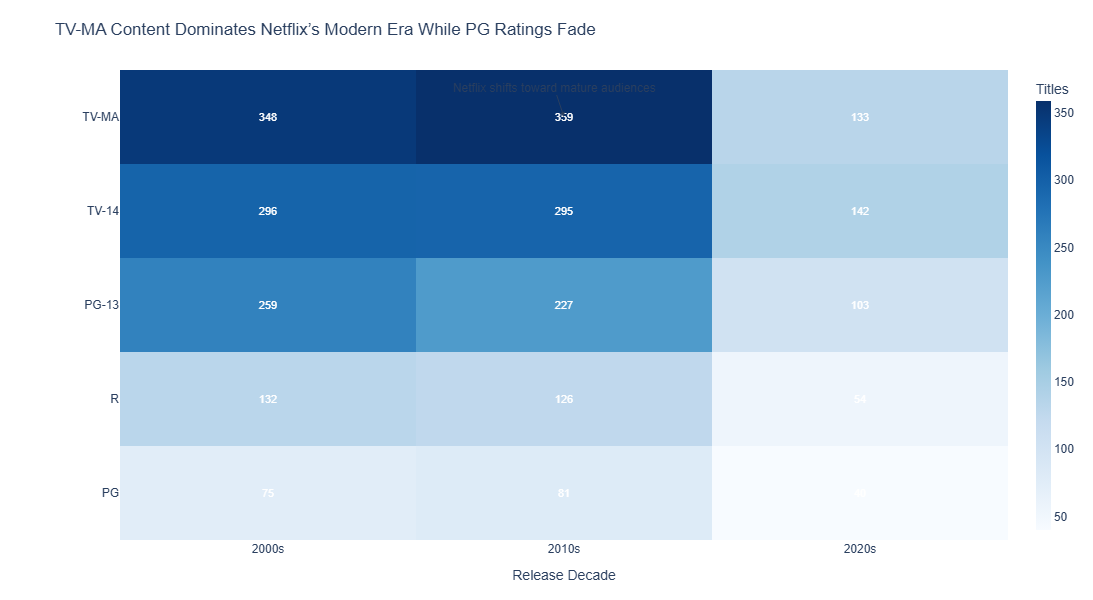

In [2]:
# ============================================================
# TASK 1 — HEATMAP: Content by Rating and Release Decade
# ============================================================

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Keep only major ratings
ratings_keep = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

heat_df = df[df['rating'].isin(ratings_keep)]

# Group data
rating_decade = (
    heat_df
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

# Pivot table
pivot = rating_decade.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

# Sort ratings by total count
pivot = pivot.loc[
    pivot.sum(axis=1).sort_values(ascending=False).index
]

# ── Plotly Express base chart ───────────────────────────────
fig = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto',
    width=1000,
    height=600,
    labels={'color': 'Number of Titles'}
)

# ── Styling ─────────────────────────────────────────────────
fig.update_traces(
    textfont=dict(size=11, color='white'),
    hovertemplate='<b>%{y}</b> — %{x}<br>Titles: %{z}<extra></extra>'
)

fig.update_layout(
    title='TV-MA Content Dominates Netflix’s Modern Era While PG Ratings Fade',
    font=dict(family='Arial', size=12),
    margin=dict(l=120, r=40, t=70, b=60),
    coloraxis_colorbar=dict(
        title='Titles',
        thickness=15
    ),
    xaxis=dict(title='Release Decade'),
    yaxis=dict(title='')
)

# Annotation
fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Netflix shifts toward mature audiences',
    showarrow=True,
    arrowhead=2
)

fig.show()


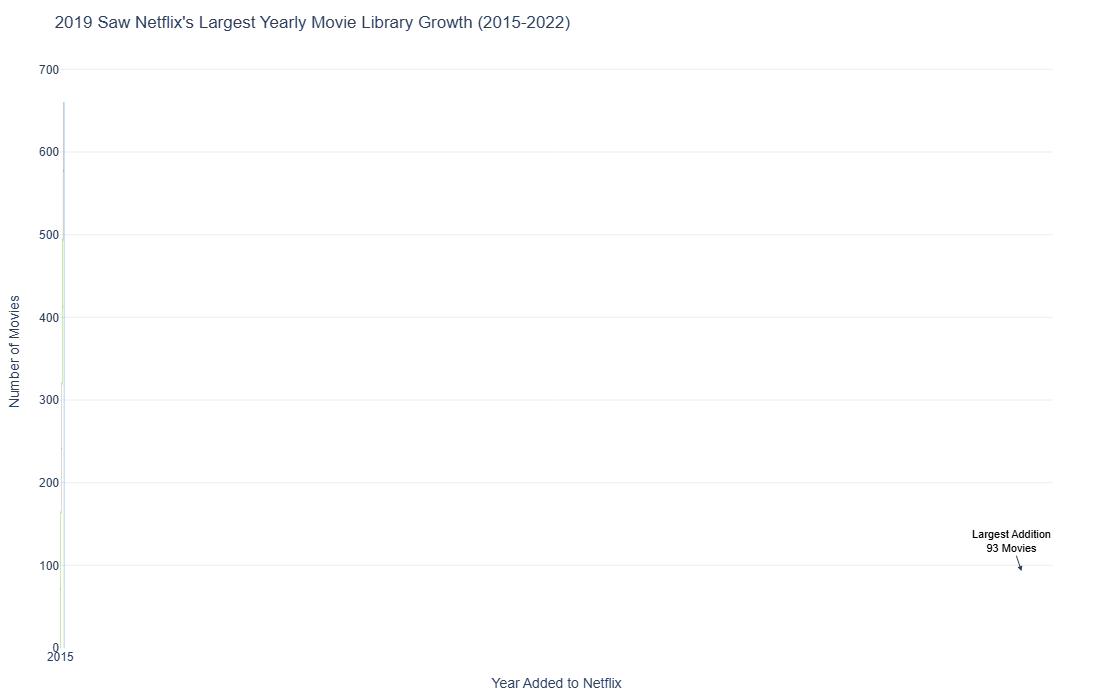

In [15]:
import pandas as pd
import plotly.graph_objects as go
# --------------------------
df_movies = df[(df['type'] == 'Movie') & (df['added_year'].between(2015, 2022))]

adds = df_movies.groupby('added_year').size().reset_index(name='new_titles')

cumulative = adds['new_titles'].sum()
max_count = adds['new_titles'].max()
max_year = adds.loc[adds['new_titles'].idxmax(), 'added_year']


# --------------------------
trace = go.Waterfall(

    x=adds['added_year'].astype(str).tolist() + ['Total Movies 2015-2022'],
   
    y=adds['new_titles'].tolist() + [cumulative],
  
    measure=['relative']*len(adds) + ['total'],
    connector=dict(line=dict(color='#AAAAAA', dash='dot')),
    increasing=dict(marker_color='#70AD47'),   
    totals=dict(marker_color='#2E75B6'),       
    texttemplate='%{y:,}',                     
    textposition='outside',
    width=0.7  # 
)

my_data = [trace]
fig = go.Figure(data=my_data)


# --------------------------
fig.add_annotation(
    x=str(max_year),
    y=max_count,
    text=f"Largest Addition<br>{max_count} Movies",
    showarrow=True,
    arrowhead=2,
    font=dict(size=11, color="black")
)


# --------------------------
fig.update_layout(
    title='2019 Saw Netflix\'s Largest Yearly Movie Library Growth (2015-2022)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    yaxis=dict(gridcolor='#EEEEEE', title='Number of Movies'),
    xaxis=dict(title='Year Added to Netflix', showgrid=False),
    margin=dict(l=60, r=40, t=55, b=40),
    showlegend=False,
    height=700
)

fig.show()